# Spectral Graph & Extended Cluster Features: Combined Dataset

This notebook applies two novel feature groups to the **combined
2500-question dataset**, alongside our 6 baseline geometric features.
Total feature space: **15 features** (6 baseline + 6 spectral + 3 extended cluster).

Pipeline: feature computation → EDA → KS tests → permutation tests →
bootstrap CI → ablation → significant-feature ablation → SHAP.

---

## Complete Feature Inventory

### Baseline (7 features: our pipeline)

| # | Symbol | Formula | Reference |
|---|--------|---------|----------|
| 1 | $H_{\text{sem}}$ | $-\sum_k p_k \log_2 p_k$ | Farquhar et al. (2024) |
| 2 | $D_{\cos}$ | $\frac{1}{N}\sum_j(1-\cos(\mathbf{e}_j,\bar{\mathbf{e}}))$ | Ricco et al. (2025) |
| 3 | $D_{\cos,\text{var}}$ | $\text{Var}_j[1-\cos(\mathbf{e}_j,\bar{\mathbf{e}})]$ |  |
| 4 | $D_{\text{pair}}$ | $\frac{1}{\binom{N}{2}}\sum_{j<k}(1-S_{jk})$ |  |
| 6 | $K$ | number of agglomerative clusters | — |
| 7 | $\sigma^2_S$ | $\text{Var}\{S_{jk}:j<k\}$ | — |

### Group A: Spectral Graph (6 features)

Graph Laplacian: $\mathbf{L}=\mathbf{D}-\mathbf{W}$, $W_{jk}=\max(S_{jk},0)$, $W_{jj}=0$, $D_{ii}=\sum_j W_{ij}$

Eigendecomposition: $0=\lambda_1\le\lambda_2\le\cdots\le\lambda_N$, eigenvectors $\mathbf{v}_1,\mathbf{v}_2,\ldots$

| # | Symbol | Formula | Interpretation |
|---|--------|---------|----------------|
| 10 | $\lambda_2$ | 2nd eigenvalue of $\mathbf{L}$ | **Fiedler value**: algebraic connectivity; low = responses diverge |
| 11 | $\lambda_3$ | 3rd eigenvalue | Together with $\lambda_2$ captures tri-partition geometry |
| 12 | SGR | $\lambda_2/(\lambda_3+\varepsilon)$ | **Spectral Gap Ratio**: clean bipartition signal |
| 13 | $H_{\text{spec}}$ | $-\sum_i q_i\log_2 q_i,\;q_i=\lambda_i/\sum_i\lambda_i$ | **Spectral Entropy**: eigenvalue spread complexity |
| 14 | IPR | $\sum_j v_2[j]^4$ | **Inverse Participation Ratio**: Fiedler vector localisation |
| 15 | HFER | $\lambda_2\times H_{\text{Fiedler}}$ | Connectivity × partition geometry |

### Group B: Extended Cluster Structure (3 features)

Cluster proportions $p_1\ge p_2\ge\cdots\ge p_K$ from agglomerative clustering.

| # | Symbol | Formula | Interpretation |
|---|--------|---------|----------------|
| 16 | $p_1$ | $\max_k p_k$ | Largest cluster fraction: model confidence |
| 17 | $p_2$ | 2nd-largest $p_k$ | Runner-up fraction: competing answer strength |
| 18 | singleton\_frac | (# singletons)$/N$ | Incoherence signal: isolated divergent responses |

---

## Explanation for the Permutation Tests on $\lambda_2$ and `singleton_cluster_frac`

The permutation test answers a targeted question: *does this specific feature
have a significantly different mean between hallucinated and correct questions?*
We pick the two features with the clearest theoretical prediction:

**$\lambda_2$ (Fiedler value):**
A confident model produces responses that all say the same thing —
the response graph is tightly connected, so $\lambda_2$ is large.
A hallucinating model produces responses that contradict each other —
the graph weakens or splits, so $\lambda_2$ is small.
The theoretical prediction is unambiguous and directional:
$\lambda_2^{\text{correct}} > \lambda_2^{\text{hallucinated}}$.
This makes it the natural candidate for a one-sided permutation test.

**`singleton_cluster_frac`:**
A singleton is a response so divergent from all others that agglomerative
clustering places it alone in its own cluster.
A hallucinating model is more likely to produce a completely different
fabricated answer: so singleton fraction should be higher for hallucinated questions.
This prediction is also directional:
$\text{singleton\_frac}^{\text{hallucinated}} > \text{singleton\_frac}^{\text{correct}}$.

The KS test checks the full distribution for all 9 new features.
The permutation test is reserved for these two because they have the
clearest prior theoretical expectation: making the result confirmatory
rather than a post-hoc correlation search.

---

## Setup

In [1]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

from spectral_detection.data.cleaning import load_dataset, add_canonical_domain, FEATURES, FEATURE_LABELS
from spectral_detection.feature_extraction import (
    extract_spectral_features,
    SPECTRAL_FEATURES, EXTENDED_CLUSTER_FEATURES,
    ALL_NEW_FEATURES, ALL_NEW_NICE_NAMES,
    SPECTRAL_NICE_NAMES, EXTENDED_CLUSTER_NICE_NAMES,
)
from spectral_detection.analysis.stats import run_ks_tests, run_permutation_test, run_bootstrap_auc
from spectral_detection.visualization import (
    plot_feature_distributions, plot_correlation_matrix,
    plot_permutation_test, plot_bootstrap_auc,
    plot_ablation_bar, plot_roc_curves, plot_ablation_roc_curves,
    plot_shap_beeswarm,
)
from spectral_detection.training import build_classifiers

sns.set_style('whitegrid')

ALL_15 = FEATURES + ALL_NEW_FEATURES   # 6 baseline + 9 new = 15 features in total! 

# and does not belong in a feature set meant to be unsupervised/geometric.
ALL_LABELS = {**FEATURE_LABELS, **ALL_NEW_NICE_NAMES}
print(f'Total features: {len(ALL_15)} (all unsupervised)')
for i, f in enumerate(ALL_15):
    print(f'  [{i:02d}] {f:35s} {ALL_LABELS.get(f, f)}')

Total features: 15 (all unsupervised)
  [00] H_sem                               Semantic Entropy
  [01] D_cos                               Cosine Dispersion (mean centroid)
  [02] D_cos_var                           Cosine Dispersion (variance centroid)
  [03] D_pair                              Mean Pairwise Cosine Distance
  [04] K                                   Cluster Count
  [05] sig2_S                              Similarity Variance
  [06] lam2                                Fiedler Value (lam2)
  [07] lam3                                Third Eigenvalue (lam3)
  [08] SGR                                 Spectral Gap Ratio (lam2/lam3)
  [09] spectral_entropy                    Spectral Entropy
  [10] ipr_fiedler                         IPR Fiedler Vector
  [11] HFER                                HFER (lam2 x Fiedler Entropy)
  [12] largest_cluster_frac                Largest Cluster Fraction
  [13] second_largest_cluster_frac         Second-Largest Cluster Fraction
  [14] s

## Configuration

In [2]:
DATA_DIR   = '../data/processed'
NPY_DIR    = '../data/temp/pny/'
CSV_DIR    = '../data/temp/processed_csv/'
OUTPUT_DIR = '../data/processed/temp/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

SIM_THRESHOLD  = 0.85
N_PERMUTATIONS = 10_000
N_BOOTSTRAP    = 2_000
SEED = 42
np.random.seed(SEED)

DATASET_FILES = {
    'defan': 'defan_t0.9_n20.jsonl', 'halueval': 'halueval_t1.0_n20.jsonl',
    'mmlu': 'mmlu_t1.0_n20.jsonl', 'triviaqa': 'triviaqa_t1.0_n20.jsonl',
    'truthfulqa': 'truthfulqa_t1.0_n20.jsonl',
}

## Load & Compute Spectral Features

In [3]:
# Load all response dataframes and embeddings
dfs, embs_list = [], []
for name, fname in DATASET_FILES.items():
    df = load_dataset(os.path.join(DATA_DIR, fname))
    if name != 'defan':
        df = add_canonical_domain(df)
    dfs.append(df)
    embs_list.append(np.load(os.path.join(NPY_DIR, f'{name}_embeddings.npy')))
    print(f'{name}: {len(df):,} responses')

df_combined = pd.concat(dfs, ignore_index=True)
emb_combined = np.vstack(embs_list)
print(f'\nCombined: {len(df_combined):,} responses, shape={emb_combined.shape}')

defan: 10,000 responses
halueval: 10,000 responses
mmlu: 10,000 responses
triviaqa: 10,000 responses
truthfulqa: 10,000 responses

Combined: 50,000 responses, shape=(50000, 384)


In [4]:
# Baseline features from notebook 03
feat_base = pd.read_csv(os.path.join(CSV_DIR, 'combined_features.csv')).set_index('prompt_id')

# Compute spectral + cluster features
feat_spectral = extract_spectral_features(df_combined, emb_combined, sim_threshold=SIM_THRESHOLD)

# Merge into full 16-feature matrix
feat_df = feat_base.join(feat_spectral[ALL_NEW_FEATURES], how='inner').reset_index()
print(f'Full feature matrix: {feat_df.shape}')
feat_df.to_csv(os.path.join(OUTPUT_DIR, 'spectral_features_combined.csv'), index=False)
display(feat_df[ALL_15].describe().round(4))

Vectorised path: 2500 q x 20 resp
  500/2500 ...
  1000/2500 ...
  1500/2500 ...
  2000/2500 ...
  2500/2500 ...

Spectral features: 2500 questions.
Full feature matrix: (2500, 39)


,H_sem,D_cos,D_cos_var,D_pair,K,sig2_S,lam2,lam3,SGR,spectral_entropy,ipr_fiedler,HFER,largest_cluster_frac,second_largest_cluster_frac,singleton_cluster_frac
count,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000
mean,2.2504,0.1874,0.0174,0.3371,9.1116,0.0412,8.0819,10.0275,0.7683,4.2099,0.5961,27.0917,0.4958,0.1115,0.3529
std,1.5546,0.1394,0.0168,0.2322,6.5776,0.0348,6.0345,5.8728,0.2183,0.0382,0.2970,20.7364,0.3406,0.0911,0.3275
min,-0.0000,-0.0000,0.0000,-0.0000,1.0000,0.0000,-0.0000,1.0629,-0.0000,3.9096,0.0500,-0.0000,0.0500,0.0000,0.0000
25%,0.7476,0.0583,0.0042,0.1192,3.0000,0.0142,3.0837,4.8233,0.6572,4.1893,0.3214,10.5535,0.1500,0.0500,0.0500
50%,2.4192,0.1805,0.0128,0.3456,8.0000,0.0353,5.8702,8.8268,0.8335,4.2191,0.6844,20.0130,0.4500,0.1000,0.2500
75%,3.7842,0.2893,0.0260,0.5210,15.0000,0.0596,11.8690,14.5090,0.9342,4.2419,0.8904,38.3157,0.8500,0.1500,0.6500
max,4.3219,0.5781,0.1369,0.8653,20.0000,0.2523,20.0000,20.0000,1.0000,4.2479,0.9026,84.6611,1.0000,0.5000,1.0000


## EDA

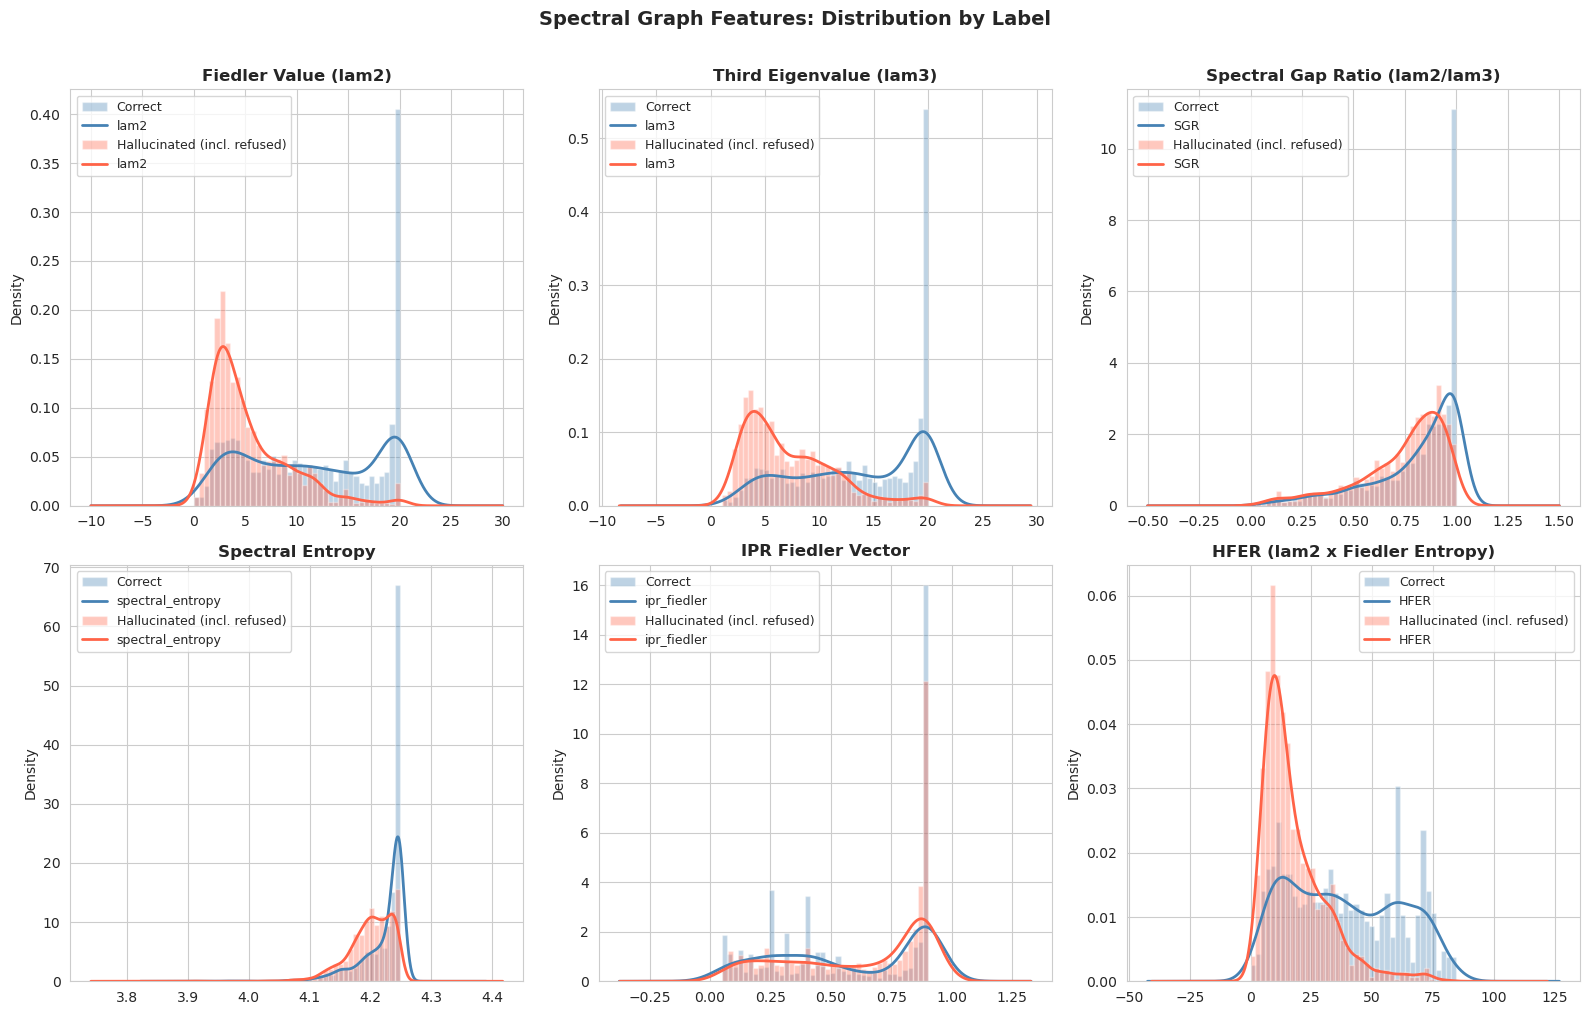

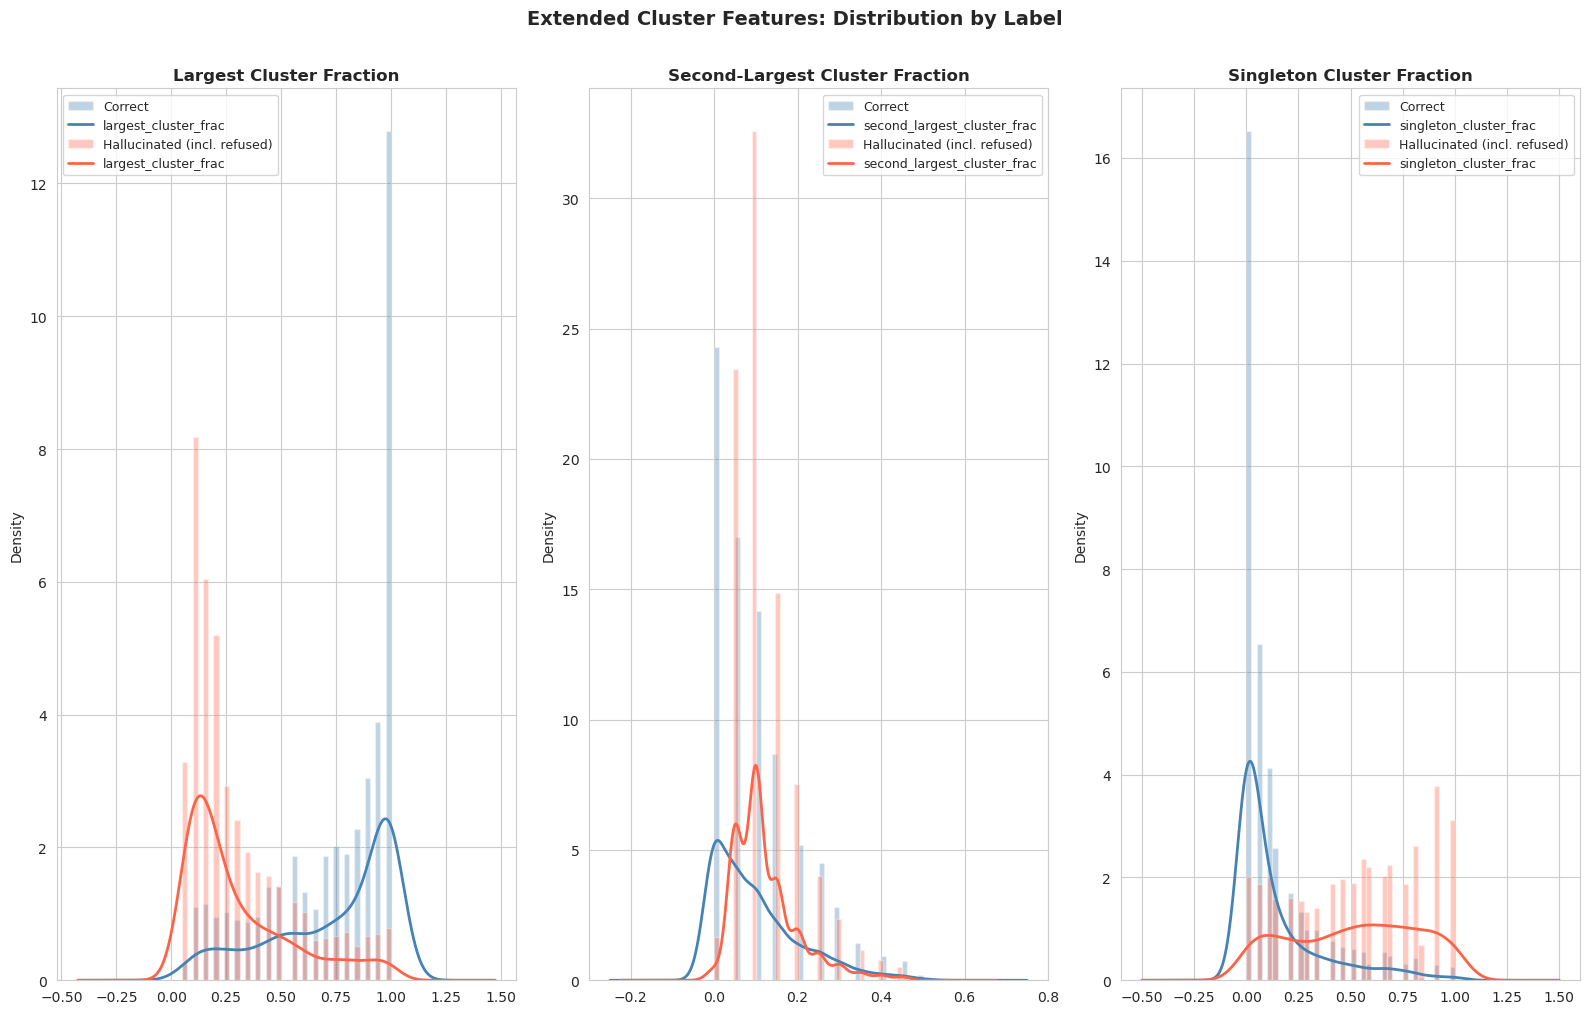

In [5]:
# Spectral feature distributions
fig = plot_feature_distributions(
    feat_df, geo_features=SPECTRAL_FEATURES, feat_nice=SPECTRAL_NICE_NAMES,
    suptitle='Spectral Graph Features: Distribution by Label')
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_feat_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

# Extended cluster distributions
fig = plot_feature_distributions(
    feat_df, geo_features=EXTENDED_CLUSTER_FEATURES, feat_nice=EXTENDED_CLUSTER_NICE_NAMES,
    suptitle='Extended Cluster Features: Distribution by Label')
plt.savefig(os.path.join(OUTPUT_DIR, 'ext_cluster_feat_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

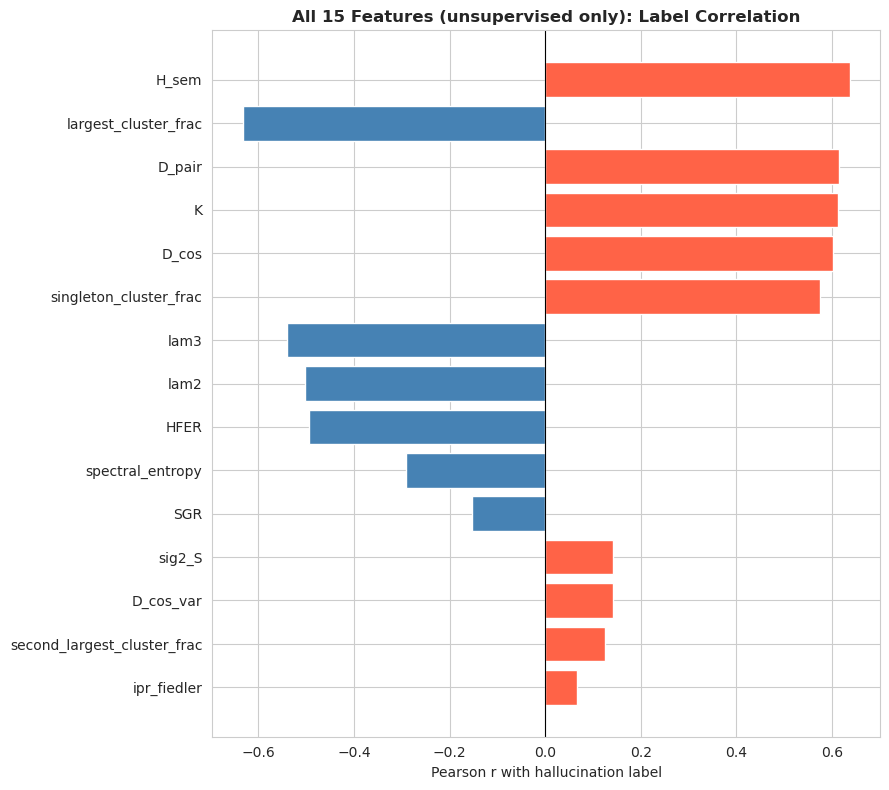

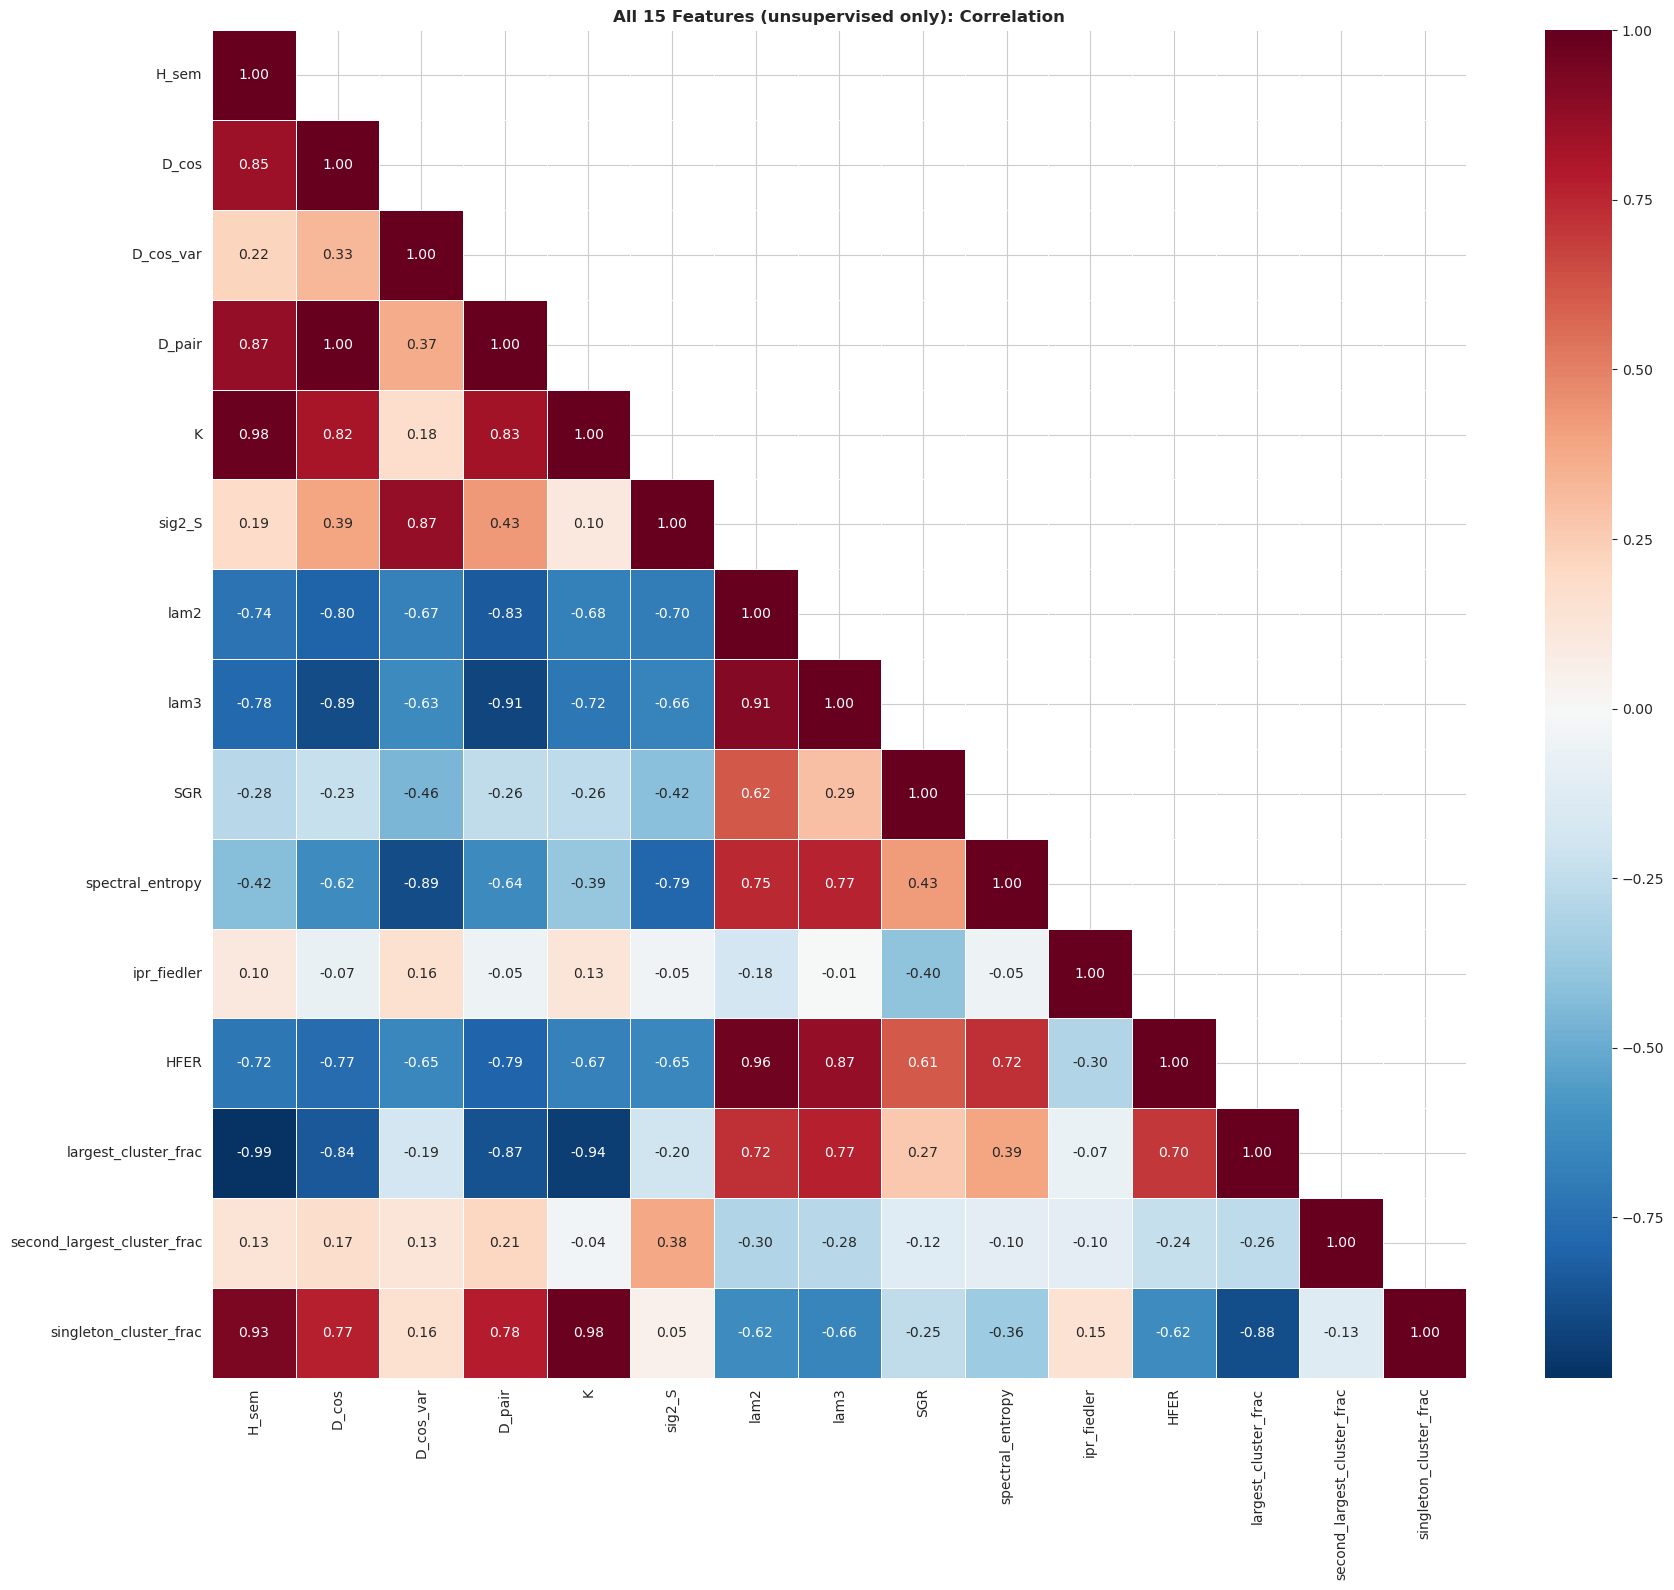

In [6]:
# Correlation with hallucination label
corr_label = (
    feat_df[ALL_15 + ['label']].corr(numeric_only=True)['label']
    .drop('label').sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_label]
ax.barh(corr_label.index[::-1], corr_label.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with hallucination label')
ax.set_title('All 15 Features (unsupervised only): Label Correlation', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_corr_label.png'), dpi=150, bbox_inches='tight')
plt.show()

# Full correlation heatmap
fig = plot_correlation_matrix(feat_df, cols=ALL_15, title='All 15 Features (unsupervised only): Correlation', figsize=(18, 16))
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_corr_all.png'), dpi=150, bbox_inches='tight')
plt.show()

## Statistical Tests

KS tests on the 9 new features, permutation tests on lam2 and singleton_frac,
bootstrap CI on three feature sets.

### KS Tests: All New Features

$H_0$: the feature has the same distribution for hallucinated and correct questions.
Bonferroni correction: $\alpha_{adj} = 0.05 / 9 = 0.0056$.

### Permutation Test: Fiedler Value λ₂

H₀: mean(λ₂ | y=0) = mean(λ₂ | y=1).
We sign-flip λ₂ so that 'higher = worse' (hallucinated), matching
the convention of the other tests. See the header for the theoretical
justification for choosing this feature.

### Permutation Test: Singleton Cluster Fraction

H₀: mean(singleton_frac | y=1) = mean(singleton_frac | y=0).
See header for justification.

### Bootstrap CI on AUC-ROC

We run bootstrap (B=2000, OOB evaluation) for three feature sets:
spectral-only (6 features), all 9 new features, and the full 15-feature set.

In [7]:
# KS tests: Bonferroni across 9 new features: alpha_adj = 0.05/9
ks_df = run_ks_tests(feat_df, features=ALL_NEW_FEATURES, alpha=0.05)
ks_df.to_csv(os.path.join(OUTPUT_DIR, 'spectral_ks_tests.csv'), index=False)
display(ks_df)

KS tests (Bonferroni alpha=0.0056, 9 tests):
  +  lam2          D=0.4297  p=9.45e-103  ***
  +  lam3          D=0.4829  p=6.97e-131  ***
  +  SGR           D=0.2539  p=1.95e-35  ***
  +  spectral_entropy  D=0.3866  p=9.45e-83  ***
  +  ipr_fiedler   D=0.1320  p=7.80e-10  ***
  +  HFER          D=0.4342  p=5.65e-105  ***
  +  largest_cluster_frac  D=0.5834  p=4.92e-195  ***
  +  second_largest_cluster_frac  D=0.2851  p=1.10e-44  ***
  +  singleton_cluster_frac  D=0.5599  p=1.13e-178  ***


,Feature,KS_stat,p_value,sig,Significant
0,lam2,0.4297,9.452354e-103,***,True
1,lam3,0.4829,6.972002e-131,***,True
2,SGR,0.2539,1.951618e-35,***,True
3,spectral_entropy,0.3866,9.446141e-83,***,True
4,ipr_fiedler,0.1320,7.801238e-10,***,True
5,HFER,0.4342,5.648685e-105,***,True
6,largest_cluster_frac,0.5834,4.922711e-195,***,True
7,second_largest_cluster_frac,0.2851,1.103122e-44,***,True
8,singleton_cluster_frac,0.5599,1.129557e-178,***,True


Permutation test (10,000 iterations):
  Observed delta = 6.1074
  p-value        = 0.000100


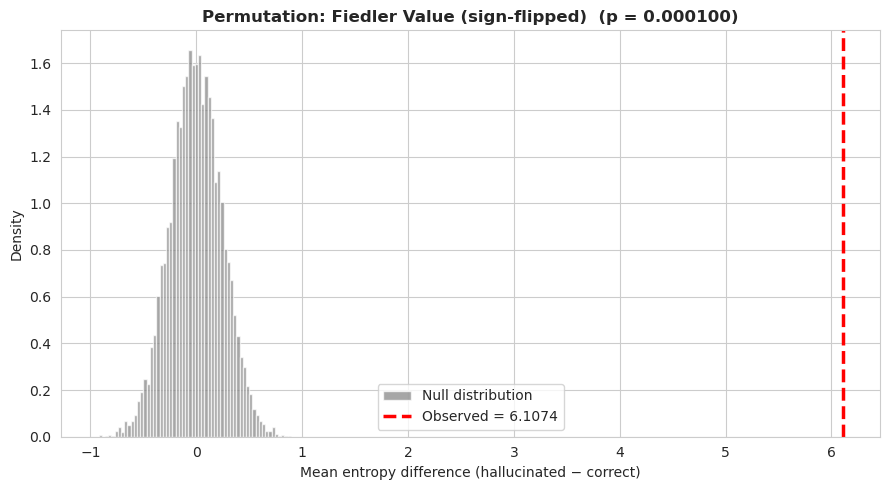

Permutation test (10,000 iterations):
  Observed delta = 0.3796
  p-value        = 0.000100


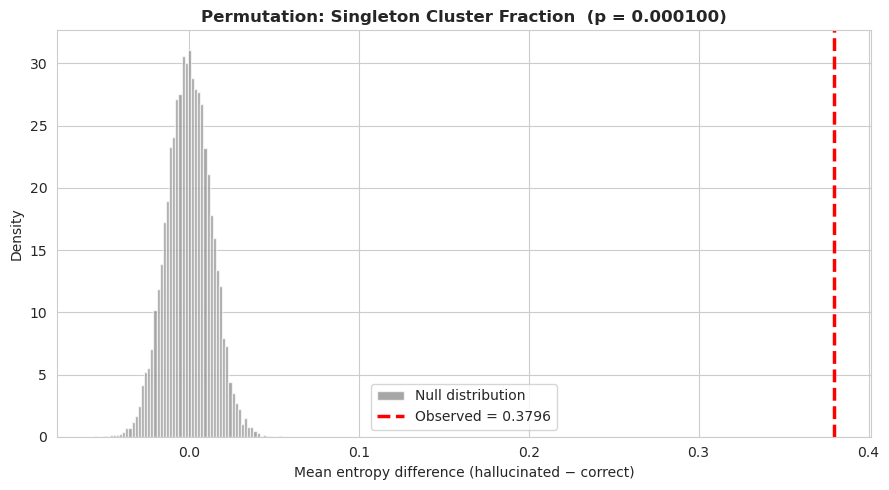

In [8]:
# Permutation: Fiedler value (sign-flipped so higher = worse)
feat_df['lam2_neg'] = -feat_df['lam2']
delta_lam2, null_lam2, pval_lam2 = run_permutation_test(
    feat_df, entropy_col='lam2_neg', n_permutations=N_PERMUTATIONS, random_seed=SEED)
fig = plot_permutation_test(null_lam2, delta_lam2, N_PERMUTATIONS, pval_lam2,
                            title='Permutation: Fiedler Value (sign-flipped)')
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_perm_lam2.png'), dpi=150, bbox_inches='tight')
plt.show()

# Permutation: singleton fraction
delta_sing, null_sing, pval_sing = run_permutation_test(
    feat_df, entropy_col='singleton_cluster_frac', n_permutations=N_PERMUTATIONS, random_seed=SEED)
fig = plot_permutation_test(null_sing, delta_sing, N_PERMUTATIONS, pval_sing,
                            title='Permutation: Singleton Cluster Fraction')
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_perm_singleton.png'), dpi=150, bbox_inches='tight')
plt.show()

Spectral only (6)               AUC=0.8282  95% CI [0.8061, 0.8505]
All 9 new                       AUC=0.8615  95% CI [0.8432, 0.8797]
Full 15                         AUC=0.8695  95% CI [0.8513, 0.8871]


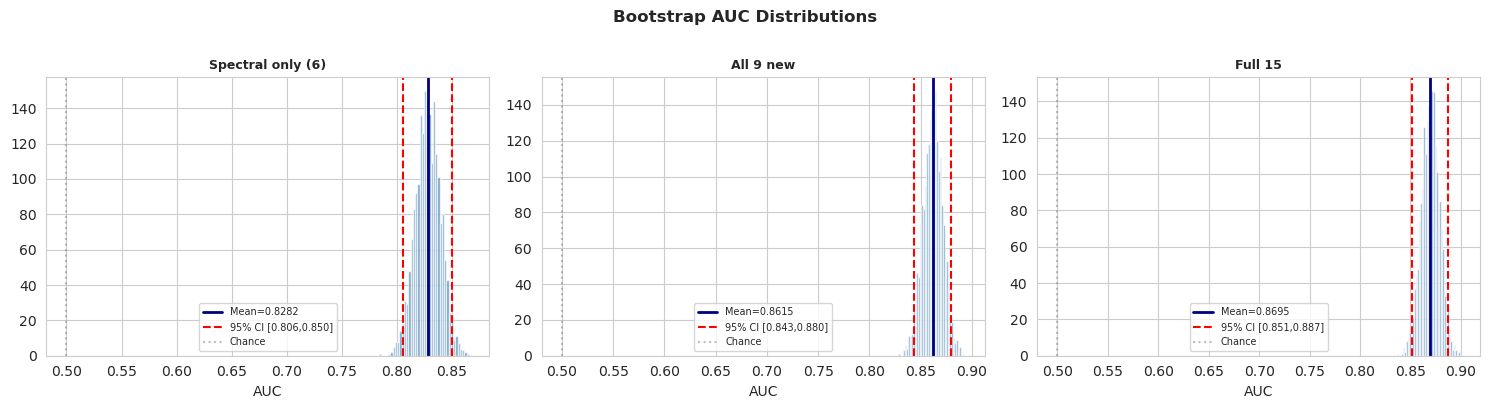

In [9]:
# Bootstrap AUC for three feature sets
boot_results = {}
for label, feats in [
    ('Spectral only (6)', SPECTRAL_FEATURES),
    ('All 9 new',         ALL_NEW_FEATURES),
    ('Full 15',           ALL_15),
]:
    boot, lo, hi = run_bootstrap_auc(feat_df, features=feats,
                                      n_bootstrap=N_BOOTSTRAP, random_seed=SEED, verbose=False)
    boot_results[label] = (boot, lo, hi)
    print(f'{label:30s}  AUC={boot.mean():.4f}  95% CI [{lo:.4f}, {hi:.4f}]')

# Side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (lbl, (boot, lo, hi)) in zip(axes, boot_results.items()):
    ax.hist(boot, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(boot.mean(), color='navy', lw=2, label=f'Mean={boot.mean():.4f}')
    ax.axvline(lo, color='red', lw=1.5, ls='--')
    ax.axvline(hi, color='red', lw=1.5, ls='--', label=f'95% CI [{lo:.3f},{hi:.3f}]')
    ax.axvline(0.5, color='gray', ls=':', alpha=0.5, label='Chance')
    ax.set_title(lbl, fontweight='bold', fontsize=9); ax.set_xlabel('AUC'); ax.legend(fontsize=7)
plt.suptitle('Bootstrap AUC Distributions', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_bootstrap_all.png'), dpi=150, bbox_inches='tight')
plt.show()

### Classification & Ablation

Three primary ablation variants: spectral graph only, all 9 new features,
and the full 15-feature pipeline: across all five classifiers.

---
A fourth variant tests only the most significant features identified by KS tests.

Classifier,ElasticNet Logit,Gradient Boosting,Logistic Regression,Random Forest,XGBoost
Variant,,,,,
All 9 new,0.867,0.852,0.867,0.863,0.842
Full 15,0.877,0.863,0.877,0.870,0.848
Most significant,0.875,0.860,0.875,0.869,0.849
Spectral only,0.834,0.835,0.833,0.832,0.825


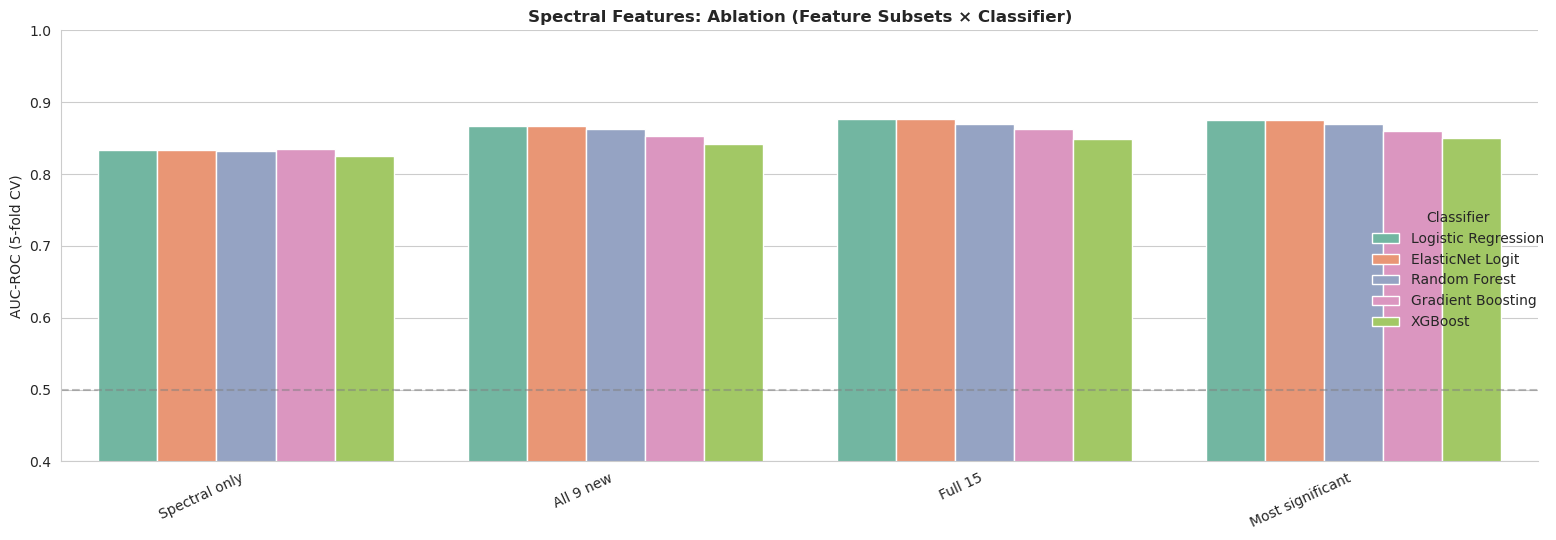

In [13]:
classifiers = build_classifiers(SEED)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

X_scaled = StandardScaler().fit_transform(feat_df[ALL_15].values)
y = feat_df['label'].values
feat_to_idx = {f: i for i, f in enumerate(ALL_15)}

# KS-significant + top correlated baseline features
sig_feats = ks_df[ks_df['Significant']]['Feature'].tolist()
top_baseline = corr_label[FEATURES].abs().sort_values(ascending=False).head(4).index.tolist()
sig_combined = list(dict.fromkeys(top_baseline + sig_feats))

ABLATION = {
    'Spectral only':     SPECTRAL_FEATURES,
    'All 9 new':         ALL_NEW_FEATURES,
    'Full 15':           ALL_15,
    'Most significant':  sig_combined,
}

rows = []
for variant, feats in ABLATION.items():
    idx = [feat_to_idx[f] for f in feats]
    X_sub = X_scaled[:, idx]
    for clf_name, clf in classifiers.items():
        scores = cross_val_score(clf, X_sub, y, cv=cv, scoring='roc_auc')
        rows.append({'Variant': variant, 'Classifier': clf_name,
                     'AUC_mean': scores.mean(), 'AUC_std': scores.std()})

df_abl = pd.DataFrame(rows)
df_abl.to_csv(os.path.join(OUTPUT_DIR, 'spectral_ablation.csv'), index=False)
display(df_abl.pivot_table(index='Variant', columns='Classifier', values='AUC_mean').round(3))

fig = plot_ablation_bar(df_abl, dataset_name='Spectral Features:')
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_ablation_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## SHAP

SHAP beeswarm on (a) all 9 new features, (b) the full 15-feature pipeline.
Red = high feature value, blue = low. Right of centre = increases hallucination score.

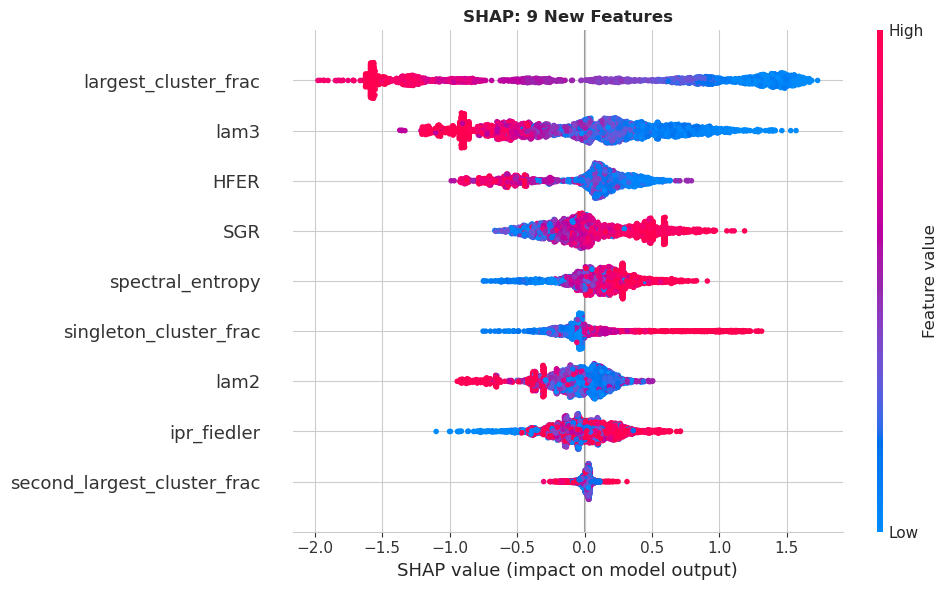

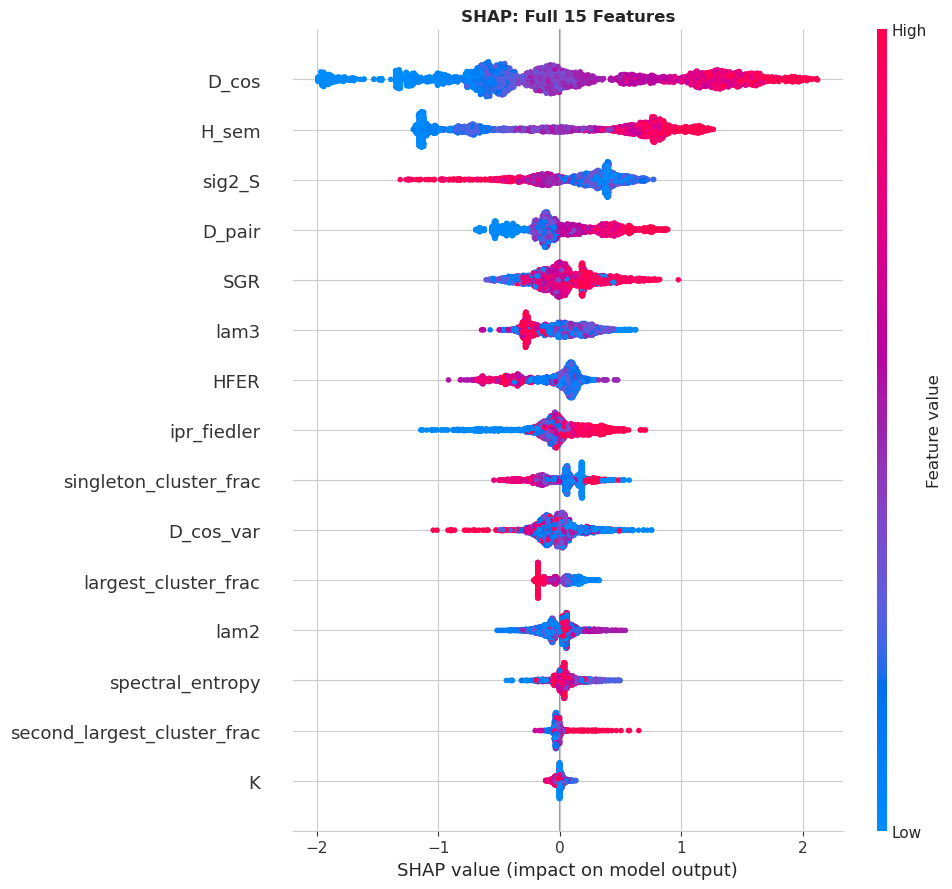

In [11]:
idx_new = [feat_to_idx[f] for f in ALL_NEW_FEATURES]
fig = plot_shap_beeswarm(X_scaled[:, idx_new], y, geo_features=ALL_NEW_FEATURES,
                         title='SHAP: 9 New Features', figsize=(10, 6))
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_shap_new.png'), dpi=150, bbox_inches='tight')
plt.show()

fig = plot_shap_beeswarm(X_scaled, y, geo_features=ALL_15,
                         title='SHAP: Full 15 Features', figsize=(10, 9))
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_shap_full.png'), dpi=150, bbox_inches='tight')
plt.show()

## Summary

In [12]:
print('=' * 60)
print('SPECTRAL GRAPH FEATURES: SUMMARY')
print('=' * 60)
print(f'  Questions: {len(feat_df):,}')
print(f'  Features:  {len(ALL_15)} (6 baseline + 6 spectral + 3 cluster)')
print(f'  Hallu rate: {feat_df["label"].mean()*100:.1f}%')
print(f'  KS-significant: {ks_df[ks_df["Significant"]]["Feature"].tolist()}')
print()
for lbl, (boot, lo, hi) in boot_results.items():
    print(f'  Bootstrap {lbl:20s}: AUC={boot.mean():.4f} [{lo:.4f}, {hi:.4f}]')
print()
best = df_abl.loc[df_abl['AUC_mean'].idxmax()]
print(f'  Best: {best["Classifier"]} / {best["Variant"]}  AUC={best["AUC_mean"]:.4f}')
print('=' * 60)

SPECTRAL GRAPH FEATURES: SUMMARY
  Questions: 2,500
  Features:  15 (6 baseline + 6 spectral + 3 cluster)
  Hallu rate: 55.8%
  KS-significant: ['lam2', 'lam3', 'SGR', 'spectral_entropy', 'ipr_fiedler', 'HFER', 'largest_cluster_frac', 'second_largest_cluster_frac', 'singleton_cluster_frac']

  Bootstrap Spectral only (6)   : AUC=0.8282 [0.8061, 0.8505]
  Bootstrap All 9 new           : AUC=0.8615 [0.8432, 0.8797]
  Bootstrap Full 15             : AUC=0.8695 [0.8513, 0.8871]

  Best: Logistic Regression / Full 15  AUC=0.8768
